In [35]:
from dataclasses import dataclass

from mesa import Agent, Model

from mesa.space import SingleGrid

from mesa.datacollection import DataCollector

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

import numpy as np
import pandas as pd

In [51]:
@dataclass
class CellWalls:
    #Estado de las 4 paredes de una celda: 2 = intacta, 1 = dañada, 0 = destruida/sin pared
    up: int = 0
    down: int = 0
    left: int = 0
    right: int = 0


class EnvironmentManager(Model):
    #Dirección opuesta usada para sincronizar el daño con la celda vecina
    OPPOSITE_DIRECTIONS = {"up": "down", "down": "up", "left": "right", "right": "left"}
    #Desplazamiento (drow, dcolumn) hacia la celda vecina según la dirección de la pared
    NEIGHBOR_OFFSETS = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

    def __init__(self, columns, rows, wall_layout=None):
        super().__init__()

        self.columns = columns
        self.rows = rows
        self._total_damage_markers = 0
        self.grid = [
            [CellWalls() for _ in range(columns)]
            for _ in range(rows)
        ]

        if wall_layout:
            self.load_wall_layout(wall_layout)

    def load_wall_layout(self, wall_layout):
        #Cada entrada es un diccionario {row, column, direction, state}
        for wall in wall_layout:
            self._set_wall(
                wall["row"],
                wall["column"],
                wall["direction"],
                wall["state"]
            )

    def _set_wall(self, row, column, direction, value):
        setattr(self.grid[row][column], direction, value)

        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.grid[nrow][ncolumn], opposite, value)

    @property
    def total_damage_markers(self):
        return self._total_damage_markers

    def damage_wall(self, row: int, column: int, direction: str):
        if direction not in self.NEIGHBOR_OFFSETS:
            raise ValueError(f"Dirección inválida: {direction}")

        cell = self.grid[row][column]
        current_value = getattr(cell, direction)
        if current_value > 0:
            setattr(cell, direction, current_value - 1)
            self._total_damage_markers += 1

        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            neighbor = self.grid[nrow][ncolumn]
            neighbor_value = getattr(neighbor, opposite)
            if neighbor_value > 0:
                setattr(neighbor, opposite, neighbor_value - 1)
                self._total_damage_markers += 1


In [72]:
#Paredes del tablero (2 = intacta), coordenadas 0-indexadas tal como se ven en la gráfica
initial_wall_layout = (
    #Contorno exterior
    [{"row": 0, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 0, "direction": "right", "state": 2} for row in range(1, 7)] +
    [{"row": 6, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 8, "direction": "right", "state": 2} for row in range(1, 7)] +

    #Divisiones interiores
    [{"row": 4, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 7, "direction": "right", "state": 2} for row in range(5, 7)] +
    [
        {"row": 3, "column": 6, "direction": "right", "state": 2},
        {"row": 4, "column": 2, "direction": "right", "state": 2},
        {"row": 4, "column": 6, "direction": "right", "state": 2},
        {"row": 3, "column": 2, "direction": "right", "state": 2},
        {"row": 5, "column": 5, "direction": "right", "state": 2},
        {"row": 6, "column": 5, "direction": "right", "state": 2},
    ] +
    [{"row": row, "column": 3, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": row, "column": 5, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": 3, "column": column, "direction": "up", "state": 2} for column in range(3, 9)]
)


In [38]:
#class FirefighterAgent(Agent):

In [53]:
class FireRescueModel(Model):
    def __init__(self, columns, rows, num_players):
        super().__init__()

        self.columns = columns
        self.rows = rows

        # Grid para los bomberos (agentes)
        self.FigthersGrid = SingleGrid(columns, rows, torus=False)

        # Matriz para los objetos de tipo fuego/humo
        self.fireCells = np.zeros((rows, columns), dtype=int)

        # Manejador de paredes y puertas, cargado con las coordenadas iniciales del tablero
        self.environment = EnvironmentManager(columns, rows, initial_wall_layout)

        # Coordenadas de fuegos existentes al inicio del juego (row, column)
        initialFires = [
            (2, 2),
            (2, 3),
            (3, 2),
            (3, 3),
            (3, 4),
            (3, 5),
            (4, 4),
            (5, 6),
            (5, 7),
            (6, 6)
        ]

        for row, column in initialFires:
            self.fireCells[row, column] = 2  # 2 equivale a fuego


    def advanceFire(self):
        # Simula el tiro de dados para ir a la casilla
        # donde debe avanzar el fuego
        row = self.random.randrange(self.rows)
        column = self.random.randrange(self.columns)

        if self.fireCells[row, column] == 0:
            # No hay ni fuego ni humo en la casilla
            if self.check_adjacentFires(row, column):
                self.fireCells[row, column] = 2
                # Si hay fuegos adyacentes se añade fuego
            else:
                self.fireCells[row, column] = 1
                # Si no hay fuegos adyacentes se añade humo

        elif self.fireCells[row, column] == 1:
            # Hay humo en la casilla, se añade fuego
            self.fireCells[row, column] = 2

        elif self.fireCells[row, column] == 2:
            # Hay fuego en la casilla, se genera una explosión
            self.explosion(row, column)


    def check_adjacentFires(self, row, column):
        # Coordenadas adyacentes dentro de la matriz
        neighbors = [
            (row - 1, column),  # arriba
            (row + 1, column),  # abajo
            (row, column - 1),  # izquierda
            (row, column + 1)   # derecha
        ]

        for neighbor_row, neighbor_column in neighbors:

            # Revisa que la coordenada esté dentro de la matriz
            if (0 <= neighbor_row < self.rows and
                0 <= neighbor_column < self.columns):

                if self.fireCells[neighbor_row, neighbor_column] == 2:
                    return True

        return False


    # def explosion(row, column):


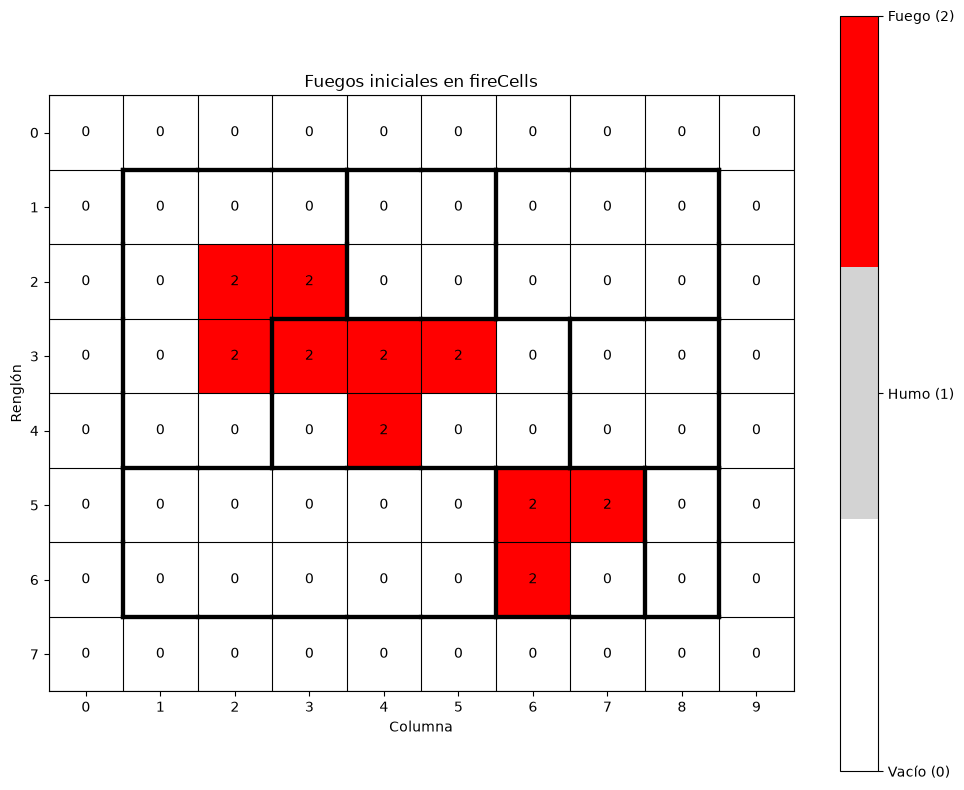

In [73]:
# Configuración inicial de dimensiones y modelo
columns = 10
rows = 8
num_players = 6

model = FireRescueModel(columns, rows, num_players)

# Muestra la matriz de los fuegos, igual al tablero inicial del juego
fig, axis = plt.subplots(figsize=(10, 8))

image = axis.imshow(
    model.fireCells,
    origin="upper",
    cmap=matplotlib.colors.ListedColormap(["white", "lightgray", "red"]),
    vmin=0,
    vmax=2
)

axis.set_title("Fuegos iniciales en fireCells")
axis.set_xlabel("Columna")
axis.set_ylabel("Renglón")

axis.set_xticks(range(columns))
axis.set_yticks(range(rows))

axis.set_xticks(np.arange(-0.5, columns, 1), minor=True)
axis.set_yticks(np.arange(-0.5, rows, 1), minor=True)

axis.grid(which="minor", color="black", linewidth=0.8)
axis.tick_params(which="minor", bottom=False, left=False)

# Renderizado de números dentro de las celdas
for row in range(rows):
    for column in range(columns):
        axis.text(
            column,
            row,
            str(model.fireCells[row, column]),
            ha="center",
            va="center"
        )

# Dibuja las paredes intactas (valor 2) sobre los bordes de cada celda
for row in range(model.environment.rows):
    for column in range(model.environment.columns):
        cell = model.environment.grid[row][column]
        x_left, x_right = column - 0.5, column + 0.5
        y_top, y_bottom = row - 0.5, row + 0.5

        if cell.up == 2:
            axis.plot([x_left, x_right], [y_top, y_top], color="black", linewidth=3, zorder=3)
        if cell.down == 2:
            axis.plot([x_left, x_right], [y_bottom, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.left == 2:
            axis.plot([x_left, x_left], [y_top, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.right == 2:
            axis.plot([x_right, x_right], [y_top, y_bottom], color="black", linewidth=3, zorder=3)

colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Vacío (0)", "Humo (1)", "Fuego (2)"])

fig.tight_layout()
plt.show()